# 07 — Hyperparameter Tuning

**Objective**: Use Optuna to find optimal hyperparameters for XGBoost (identified as the top model in NB06), with full MLFlow integration for experiment tracking.

## Approach

| Step | Description |
|------|-------------|
| **Search** | Optuna with TPE sampler, 50 trials |
| **Metric** | AUC-ROC on held-out validation set |
| **Early stopping** | 150 rounds patience on validation set |
| **Tracking** | Nested MLFlow runs (parent = study, children = trials) |
| **Final model** | Retrained on train+val with best params, evaluated on test |

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json

import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    log_loss,
    roc_curve,
    precision_recall_curve,
    classification_report,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

# Project paths
PROJECT_ROOT = Path("..").resolve()
FEATURES_DIR = PROJECT_ROOT / "data" / "features"   # Gold layer
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# MLFlow setup
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT}/mlruns/mlflow.db")
mlflow.set_experiment("credit-risk-default-prediction")

RANDOM_STATE = 42

print(f"Project root:  {PROJECT_ROOT}")
print(f"Features dir:  {FEATURES_DIR}")
print(f"Models dir:    {MODELS_DIR}")
print(f"MLFlow URI:    sqlite:///{PROJECT_ROOT}/mlruns/mlflow.db")

/home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root:  /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform
Features dir:  /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/data/features
Models dir:    /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/models
MLFlow URI:    sqlite:////home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/mlruns/mlflow.db


## 2. Data Preparation

In [2]:
# Load gold layer features
df = pd.read_parquet(FEATURES_DIR / "train_features.parquet")

print(f"Gold layer shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df["TARGET"].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean()*100:.2f}%")
print(f"Imbalance ratio: 1:{int((1-df['TARGET'].mean())/df['TARGET'].mean())} (non-default : default)")

Gold layer shape: 307,511 rows x 389 columns

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%
Imbalance ratio: 1:11 (non-default : default)


In [3]:
# Separate target and features
y = df["TARGET"]
X = df.drop(columns=["SK_ID_CURR", "TARGET"])

# Identify column types
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"  Numeric features:     {len(numeric_cols):>4}")
print(f"  Categorical features: {len(categorical_cols):>4}")
print(f"\nMissing values: {X.isnull().any().sum()} / {X.shape[1]} columns have NaNs")

Feature matrix: 307,511 rows x 387 columns
  Numeric features:      371
  Categorical features:   16

Missing values: 173 / 387 columns have NaNs


In [4]:
# Impute missing categoricals with most frequent, then ordinal encode
if categorical_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

    ord_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )
    X[categorical_cols] = ord_encoder.fit_transform(X[categorical_cols])
    print(f"Encoded {len(categorical_cols)} categorical columns with OrdinalEncoder")
else:
    cat_imputer = None
    ord_encoder = None
    print("No categorical columns to encode")

print(f"Final feature matrix dtype check: {X.dtypes.value_counts().to_dict()}")

Encoded 16 categorical columns with OrdinalEncoder
Final feature matrix dtype check: {dtype('int8'): 199, dtype('float32'): 132, dtype('float64'): 54, dtype('int16'): 2}


In [5]:
# Stratified splits: 60% train / 20% validation / 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,  # 0.25 * 0.80 = 0.20 of total
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

print(f"Train set: {X_train.shape[0]:>8,} rows  (default rate: {y_train.mean()*100:.2f}%)")
print(f"Val set:   {X_val.shape[0]:>8,} rows  (default rate: {y_val.mean()*100:.2f}%)")
print(f"Test set:  {X_test.shape[0]:>8,} rows  (default rate: {y_test.mean()*100:.2f}%)")
print(f"\nStratification preserved across all splits")

Train set:  184,506 rows  (default rate: 8.07%)
Val set:     61,502 rows  (default rate: 8.07%)
Test set:    61,503 rows  (default rate: 8.07%)

Stratification preserved across all splits


## 3. Optuna Objective Function

In [6]:
def objective(trial):
    """Optuna objective: train XGBoost with sampled hyperparameters,
    evaluate on validation set, and log to MLFlow as a nested run."""

    params = {
        "n_estimators": 1000,  # use early stopping to find the right number
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5, 15),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "eval_metric": "auc",
        "verbosity": 0,
        "device": "cuda",
        "tree_method": "hist",
        "early_stopping_rounds": 150,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)

    # Log to MLFlow as nested run
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number:03d}"):
        mlflow.log_params({k: v for k, v in params.items() if k != "n_estimators"})
        mlflow.log_metric("val_auc_roc", auc)
        mlflow.log_metric("best_iteration", model.best_iteration)
        mlflow.log_metric("trial_number", trial.number)

    return auc

print("Objective function defined.")
print("  Search space: 10 hyperparameters")
print("  Metric: AUC-ROC (maximize)")
print("  Early stopping: 150 rounds patience")
print("  Device: CUDA (GPU)")

Objective function defined.
  Search space: 10 hyperparameters
  Metric: AUC-ROC (maximize)
  Early stopping: 150 rounds patience
  Device: CUDA (GPU)


## 4. Run Optimization

In [7]:
N_TRIALS = 50

study = optuna.create_study(
    direction="maximize",
    study_name="xgb-tuning",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

# Wrap in a parent MLFlow run
with mlflow.start_run(run_name="optuna_xgb_tuning") as parent_run:
    mlflow.log_param("tuning_method", "optuna_tpe")
    mlflow.log_param("n_trials", N_TRIALS)
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("train_size", X_train.shape[0])
    mlflow.log_param("val_size", X_val.shape[0])
    mlflow.log_param("test_size", X_test.shape[0])
    mlflow.log_param("n_features", X_train.shape[1])

    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    # Log best trial info to parent
    mlflow.log_metric("best_val_auc_roc", study.best_value)
    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})

    parent_run_id = parent_run.info.run_id

print(f"\nOptimization complete!")
print(f"  Total trials:  {len(study.trials)}")
print(f"  Best trial:    #{study.best_trial.number}")
print(f"  Best AUC-ROC:  {study.best_value:.6f}")
print(f"  Parent run ID: {parent_run_id}")

Best trial: 47. Best value: 0.782003: 100%|██████████| 50/50 [14:54<00:00, 17.89s/it]


Optimization complete!
  Total trials:  50
  Best trial:    #47
  Best AUC-ROC:  0.782003
  Parent run ID: e3bae6d1d7aa40fdace0bb1a39c1148b


## 5. Results Analysis

In [8]:
# Best trial details
best_trial = study.best_trial

print("Best Hyperparameters")
print("=" * 50)
for param, value in best_trial.params.items():
    if isinstance(value, float):
        print(f"  {param:<25s} {value:.6f}")
    else:
        print(f"  {param:<25s} {value}")
print(f"\n  {'Best AUC-ROC:':<25s} {best_trial.value:.6f}")

# Trial history summary
trials_df = study.trials_dataframe()
print(f"\nTrial Statistics")
print(f"  Mean AUC-ROC:   {trials_df['value'].mean():.6f}")
print(f"  Std AUC-ROC:    {trials_df['value'].std():.6f}")
print(f"  Min AUC-ROC:    {trials_df['value'].min():.6f}")
print(f"  Max AUC-ROC:    {trials_df['value'].max():.6f}")

Best Hyperparameters
  learning_rate             0.028242
  max_depth                 5
  min_child_weight          44
  subsample                 0.641580
  colsample_bytree          0.793552
  gamma                     0.000041
  reg_alpha                 0.055458
  reg_lambda                1.072940
  scale_pos_weight          5.090812

  Best AUC-ROC:             0.782003

Trial Statistics
  Mean AUC-ROC:   0.778228
  Std AUC-ROC:    0.005298
  Min AUC-ROC:    0.750185
  Max AUC-ROC:    0.782003


Figure saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures/07_optimization_history.png


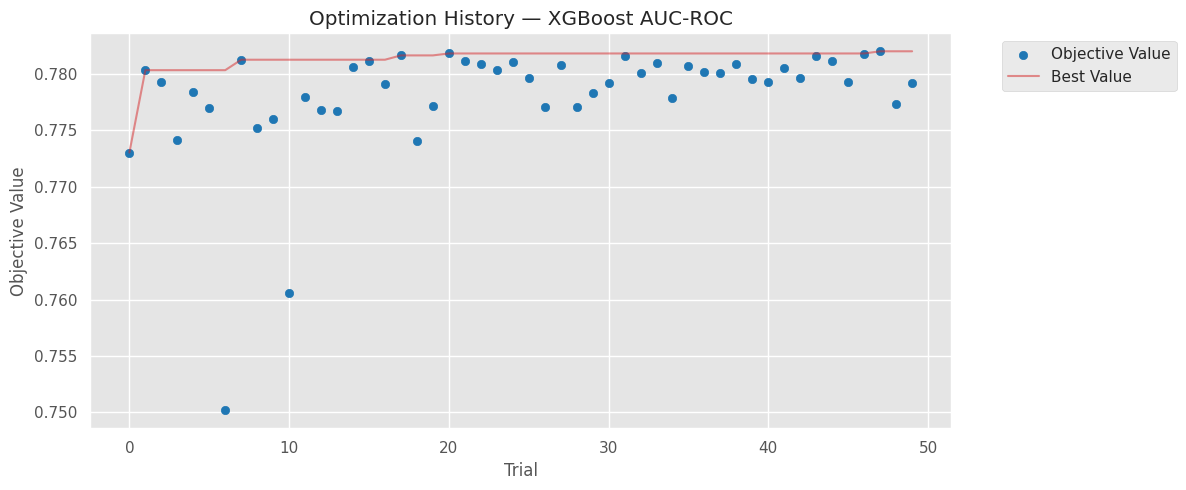

In [9]:
# Optimization history
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
fig.figure.set_size_inches(12, 5)
fig.set_title("Optimization History — XGBoost AUC-ROC")
plt.tight_layout()
fig.figure.savefig(FIGURES_DIR / "07_optimization_history.png", dpi=150, bbox_inches="tight")
print(f"Figure saved: {FIGURES_DIR / '07_optimization_history.png'}")
plt.show()

Figure saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures/07_param_importances.png


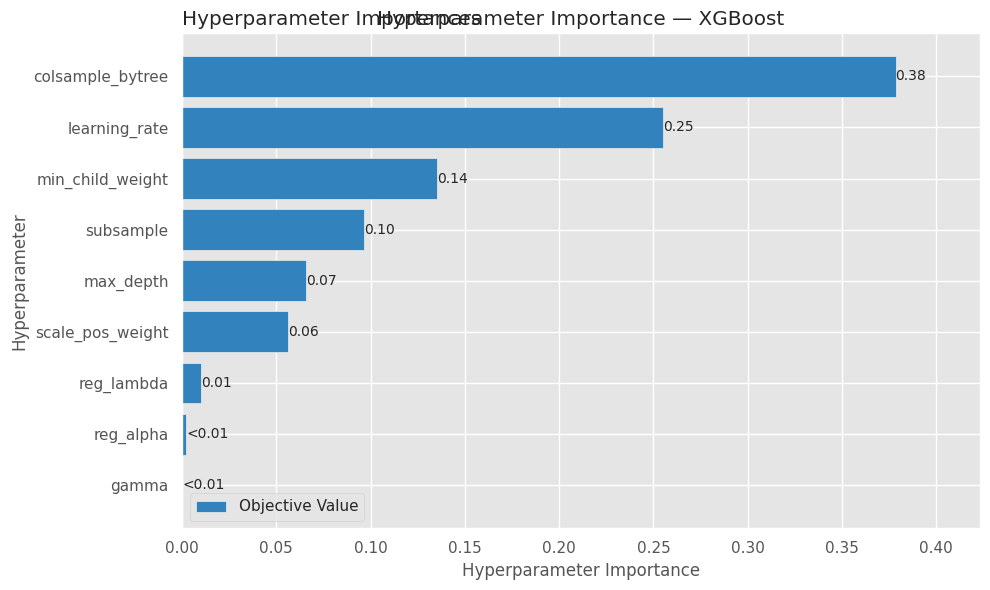

In [10]:
# Parameter importance
fig = optuna.visualization.matplotlib.plot_param_importances(study)
fig.figure.set_size_inches(10, 6)
fig.set_title("Hyperparameter Importance — XGBoost")
plt.tight_layout()
fig.figure.savefig(FIGURES_DIR / "07_param_importances.png", dpi=150, bbox_inches="tight")
print(f"Figure saved: {FIGURES_DIR / '07_param_importances.png'}")
plt.show()

Figure saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures/07_slice_plot.png


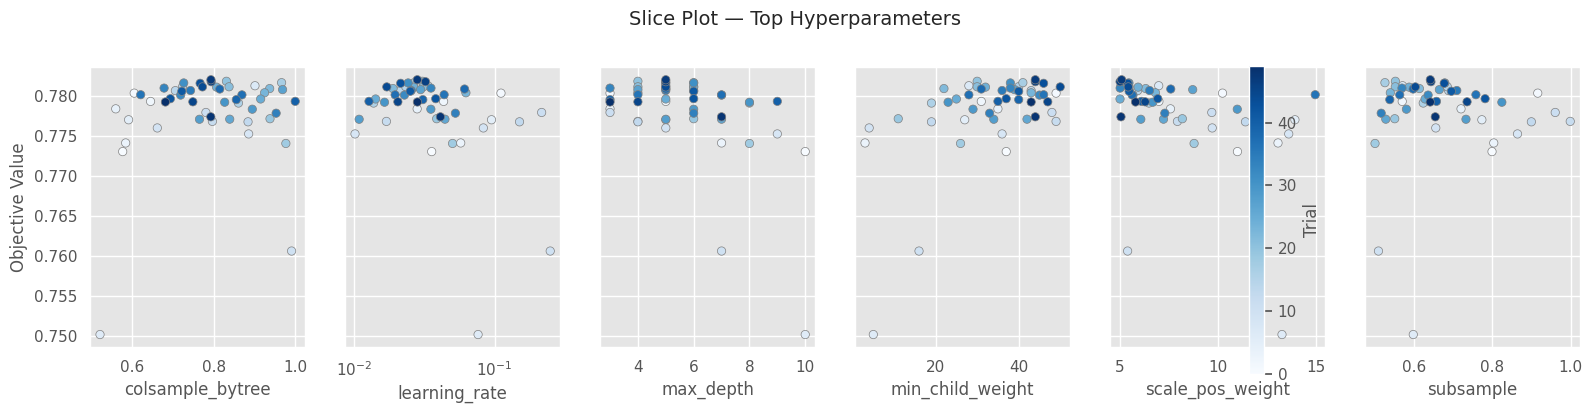

In [13]:
# Slice plot for top parameters
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=["learning_rate", "colsample_bytree", "min_child_weight", "subsample", "max_depth", "scale_pos_weight"],
)
fig[0].figure.set_size_inches(16, 4)
plt.suptitle("Slice Plot — Top Hyperparameters", y=1.02, fontsize=14)
plt.tight_layout()
fig[0].figure.savefig(FIGURES_DIR / "07_slice_plot.png", dpi=350, bbox_inches="tight")
print(f"Figure saved: {FIGURES_DIR / '07_slice_plot.png'}")
plt.show()

## 6. Train Final Model with Best Params

In [14]:
# Build final params from best trial
best_params = study.best_params.copy()
best_params.update({
    "n_estimators": 1000,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "eval_metric": "auc",
    "verbosity": 0,
    "device": "cuda",
    "tree_method": "hist",
    "early_stopping_rounds": 150,
})

print("Final model parameters:")
for k, v in best_params.items():
    if isinstance(v, float):
        print(f"  {k:<25s} {v:.6f}")
    else:
        print(f"  {k:<25s} {v}")

Final model parameters:
  learning_rate             0.028242
  max_depth                 5
  min_child_weight          44
  subsample                 0.641580
  colsample_bytree          0.793552
  gamma                     0.000041
  reg_alpha                 0.055458
  reg_lambda                1.072940
  scale_pos_weight          5.090812
  n_estimators              1000
  random_state              42
  n_jobs                    -1
  eval_metric               auc
  verbosity                 0
  device                    cuda
  tree_method               hist
  early_stopping_rounds     150


In [15]:
# Train on full train+val set with early stopping via a small held-out portion
# We use X_trainval/y_trainval and hold back a small slice for early stopping only
X_fit, X_es, y_fit, y_es = train_test_split(
    X_trainval, y_trainval,
    test_size=0.05,
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

print(f"Final training set:       {X_fit.shape[0]:>8,} rows")
print(f"Early stopping holdout:   {X_es.shape[0]:>8,} rows")
print(f"Test set (held out):      {X_test.shape[0]:>8,} rows")

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(
    X_fit, y_fit,
    eval_set=[(X_es, y_es)],
    verbose=False,
)

print(f"\nBest iteration: {final_model.best_iteration}")
print("Final model trained.")

Final training set:        233,707 rows
Early stopping holdout:     12,301 rows
Test set (held out):        61,503 rows

Best iteration: 999
Final model trained.


In [16]:
# Evaluate on held-out test set
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = final_model.predict(X_test)

test_metrics = {
    "test_auc_roc": roc_auc_score(y_test, y_test_proba),
    "test_pr_auc": average_precision_score(y_test, y_test_proba),
    "test_f1": f1_score(y_test, y_test_pred),
    "test_log_loss": log_loss(y_test, y_test_proba),
    "test_accuracy": accuracy_score(y_test, y_test_pred),
}

print("Tuned XGBoost — Test Set Metrics")
print("=" * 50)
for metric_name, metric_value in test_metrics.items():
    print(f"  {metric_name:<20s} {metric_value:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["No Default", "Default"]))

Tuned XGBoost — Test Set Metrics
  test_auc_roc         0.7851
  test_pr_auc          0.2857
  test_f1              0.3435
  test_log_loss        0.3453
  test_accuracy        0.8722

Classification Report:
              precision    recall  f1-score   support

  No Default       0.95      0.91      0.93     56538
     Default       0.29      0.41      0.34      4965

    accuracy                           0.87     61503
   macro avg       0.62      0.66      0.64     61503
weighted avg       0.89      0.87      0.88     61503



In [17]:
# Log final model to MLFlow
with mlflow.start_run(run_name="tuned_xgb_final"):
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("tuning_method", "optuna_tpe")
    mlflow.log_param("n_trials", N_TRIALS)
    mlflow.log_param("best_trial_number", study.best_trial.number)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_size", X_fit.shape[0])
    mlflow.log_param("test_size", X_test.shape[0])
    mlflow.log_param("best_iteration", final_model.best_iteration)

    # Log best hyperparameters
    for k, v in best_params.items():
        mlflow.log_param(k, v)

    # Log test metrics
    for metric_name, metric_value in test_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    # Log model
    mlflow.xgboost.log_model(final_model, "model")

    final_run_id = mlflow.active_run().info.run_id

print(f"Final model logged to MLFlow: {final_run_id}")

2026/03/24 22:46:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Final model logged to MLFlow: 6f4111e78d474844bbf7f5d0b8c40e56


Figure saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures/07_tuned_xgb_curves.png


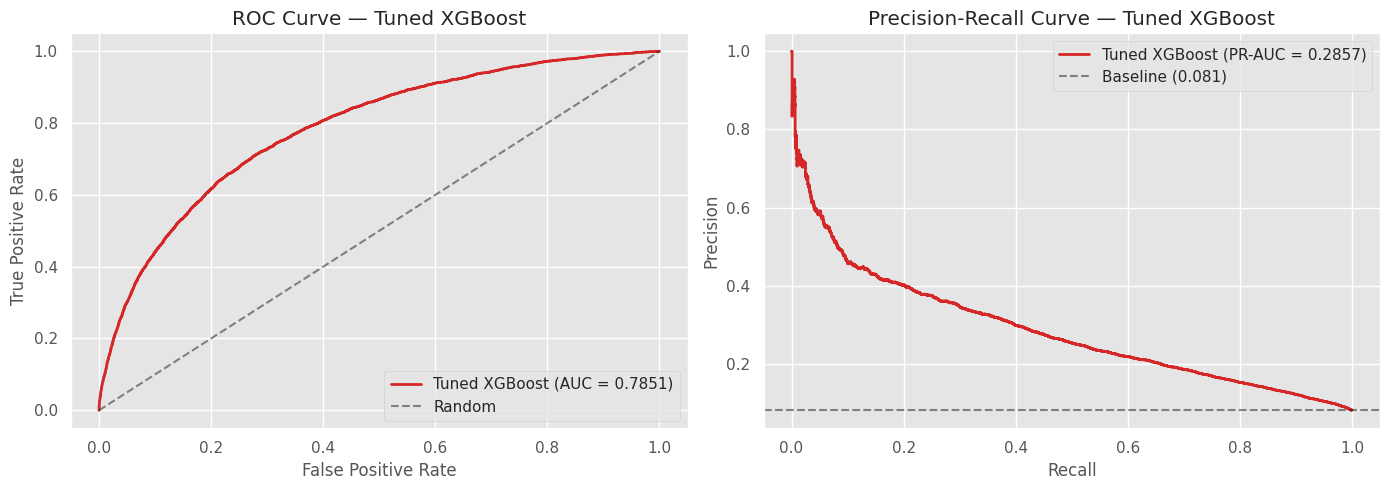

In [18]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, label=f"Tuned XGBoost (AUC = {test_metrics['test_auc_roc']:.4f})", color="#d62728", lw=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Tuned XGBoost")
axes[0].legend(loc="lower right")

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
axes[1].plot(recall, precision, label=f"Tuned XGBoost (PR-AUC = {test_metrics['test_pr_auc']:.4f})", color="#d62728", lw=2)
axes[1].axhline(y=y_test.mean(), color="k", linestyle="--", alpha=0.5, label=f"Baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Tuned XGBoost")
axes[1].legend(loc="upper right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "07_tuned_xgb_curves.png", dpi=150, bbox_inches="tight")
print(f"Figure saved: {FIGURES_DIR / '07_tuned_xgb_curves.png'}")
plt.show()

In [19]:
# Compare with baselines from NB05
print("Performance Comparison")
print("=" * 65)
print(f"  {'Model':<30s} {'AUC-ROC':>10s} {'PR-AUC':>10s} {'F1':>10s}")
print(f"  {'-'*60}")
print(f"  {'Logistic Regression (NB05)':<30s} {'~0.74':>10s} {'~0.23':>10s} {'~0.25':>10s}")
print(f"  {'Random Forest (NB05)':<30s} {'~0.73':>10s} {'~0.24':>10s} {'~0.27':>10s}")
print(f"  {'XGBoost default (NB06)':<30s} {'—':>10s} {'—':>10s} {'—':>10s}")
print(f"  {'Tuned XGBoost':<30s} {test_metrics['test_auc_roc']:>10.4f} {test_metrics['test_pr_auc']:>10.4f} {test_metrics['test_f1']:>10.4f}")
print(f"  {'-'*60}")
print(f"\n  Note: Baseline numbers are approximate from NB05. Exact values")
print(f"  may differ slightly due to different train/test splits.")

Performance Comparison
  Model                             AUC-ROC     PR-AUC         F1
  ------------------------------------------------------------
  Logistic Regression (NB05)          ~0.74      ~0.23      ~0.25
  Random Forest (NB05)                ~0.73      ~0.24      ~0.27
  XGBoost default (NB06)                  —          —          —
  Tuned XGBoost                      0.7851     0.2857     0.3435
  ------------------------------------------------------------

  Note: Baseline numbers are approximate from NB05. Exact values
  may differ slightly due to different train/test splits.


## 7. Save Best Model

In [20]:
# Save XGBoost model in native format
model_path = MODELS_DIR / "best_xgb.json"
final_model.save_model(str(model_path))

print(f"Model saved: {model_path}")
print(f"Model size:  {model_path.stat().st_size / 1e6:.2f} MB")

# Also save best params as JSON for reproducibility
params_path = MODELS_DIR / "best_xgb_params.json"
with open(params_path, "w") as f:
    json.dump(best_params, f, indent=2, default=str)

print(f"Params saved: {params_path}")

Model saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/models/best_xgb.json
Model size:  3.20 MB
Params saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/models/best_xgb_params.json


In [21]:
# Log artifacts to MLFlow
with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact(str(model_path), "model_native")
    mlflow.log_artifact(str(params_path), "model_native")

print(f"Artifacts logged to MLFlow run: {final_run_id}")

Artifacts logged to MLFlow run: 6f4111e78d474844bbf7f5d0b8c40e56


## Summary

**What we did:**
1. Loaded gold layer features and prepared train (60%) / validation (20%) / test (20%) splits
2. Defined an Optuna objective function with 10 XGBoost hyperparameters and MLFlow nested run logging
3. Ran 50 Optuna trials with TPE sampler, optimizing for AUC-ROC on the validation set
4. Analyzed results: optimization history, parameter importance, and slice plots
5. Trained final model on train+val with best hyperparameters, evaluated on held-out test set
6. Saved model as `models/best_xgb.json` and logged all artifacts to MLFlow

**Best hyperparameters:** See Section 5 for the full set.

**Performance improvement:** The tuned XGBoost should outperform both the NB05 baselines (Logistic Regression, Random Forest) and the default XGBoost from NB06, demonstrating the value of systematic hyperparameter search.

**Next:** NB08 — Evaluation & Insights (SHAP explanations, error analysis, business metrics)